In [34]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

In [35]:
class CFG:
    TARGET = ['GGFM_f']
    N_FOLDS = 5
    RANDOM_STATE = 3

    COLORADO_PATH = './Data/Synt/Colorado_600_merge.csv'
    NSO_PATH = './Data/Synt/NSO_600_merge.csv'
    COLORADO_PATH = NSO_PATH

In [36]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

class DataLoader:
    def __init__(self, colorado: pd.DataFrame, nso: pd.DataFrame):
        self.colorado = colorado.copy()
        self.nso = nso
        self.log_features = []  # Список признаков для трансформации
        self.X = None
        self.y = None
        self.scaler = StandardScaler()  # Для нормализации признаков
        self.feature_names_ = []       # Для отслеживания имён признаков

    @staticmethod
    def reduce_mem_usage(dataframe):
        """ 
        Уменьшает использование памяти dataframe путем преобразования типов данных
        с автоматическим пропуском временных столбцов
        """
        start_mem = dataframe.memory_usage().sum() / 1024**2
        print(f"Изначальное использование памяти: {start_mem:.2f} MB")
        
        for col in dataframe.columns:
            col_type = dataframe[col].dtype
            
            # Пропускаем временные столбцы и категориальные данные
            if str(col_type).startswith('datetime') or str(col_type) == 'category':
                continue
                
            if col_type != object:
                c_min = dataframe[col].min()
                c_max = dataframe[col].max()
                
                if str(col_type)[:3] == 'int':
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        dataframe[col] = dataframe[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        dataframe[col] = dataframe[col].astype(np.int16)
                    elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        dataframe[col] = dataframe[col].astype(np.int32)
                    elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                        dataframe[col] = dataframe[col].astype(np.int64)
                else:
                    if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                        dataframe[col] = dataframe[col].astype(np.float16)
                    elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        dataframe[col] = dataframe[col].astype(np.float32)
                    else:
                        dataframe[col] = dataframe[col].astype(np.float64)
            else:
                # Оптимизация строковых столбцов
                dataframe[col] = dataframe[col].astype('category')
        
        end_mem = dataframe.memory_usage().sum() / 1024**2
        print(f"Итоговое использование памяти: {end_mem:.2f} MB")
        print(f"Экономия {(start_mem - end_mem) / start_mem * 100:.1f}%")
        
        return dataframe

    def add_spherical_coordinates(self):
        """Добавляет сферические координаты (x, y, z) как направляющие косинусы"""
        lat_rad = np.radians(self.colorado['Latitude (deg)'])
        lon_rad = np.radians(self.colorado['Longitude (deg)'])
        self.colorado['sph_x'] = np.cos(lat_rad) * np.cos(lon_rad)
        self.colorado['sph_y'] = np.cos(lat_rad) * np.sin(lon_rad)
        self.colorado['sph_z'] = np.sin(lat_rad)

    def add_cartesian_coordinates(self):
        """Добавляет декартовы координаты в метрах (с учётом радиуса и высоты)"""
        R = 6378137  # средний радиус Земли в метрах
        lat_rad = np.radians(self.colorado['Latitude (deg)'])
        lon_rad = np.radians(self.colorado['Longitude (deg)'])
        h = self.colorado['Height (m)']
        
        self.colorado['cart_x'] = (R + h) * np.cos(lat_rad) * np.cos(lon_rad)
        self.colorado['cart_y'] = (R + h) * np.cos(lat_rad) * np.sin(lon_rad)
        self.colorado['cart_z'] = (R + h) * np.sin(lat_rad)

    def add_polynomial_features(self):
        """Добавляет полиномиальные признаки"""
        self.colorado['lat2'] = self.colorado['Latitude (deg)'] ** 2
        self.colorado['lon2'] = self.colorado['Longitude (deg)'] ** 2
        self.colorado['lat_lon'] = self.colorado['Latitude (deg)'] * self.colorado['Longitude (deg)']
        self.colorado['height2'] = self.colorado['Height (m)'] ** 2

    def add_local_relief_gradients(self, k=5):
        """Добавляет локальные градиенты рельефа (наклон) через KNN"""
        coords = self.colorado[['Latitude (deg)', 'Longitude (deg)']].values
        elev = self.colorado['Height (m)'].values
        grads_lat = np.zeros(len(coords))
        grads_lon = np.zeros(len(coords))

        for i in range(len(coords)):
            dists = cdist([coords[i]], coords).flatten()
            idx = np.argsort(dists)[1:k+1]  # k ближайших соседей
            dlat = self.colorado['Latitude (deg)'].iloc[idx].values - self.colorado['Latitude (deg)'].iloc[i]
            dlon = self.colorado['Longitude (deg)'].iloc[idx].values - self.colorado['Longitude (deg)'].iloc[i]
            dh = elev[idx] - elev[i]

            # Фильтрация нулевых разностей
            valid_lat = np.abs(dlat) > 1e-6
            valid_lon = np.abs(dlon) > 1e-6

            grad_lat = np.mean(dh[valid_lat] / dlat[valid_lat]) if valid_lat.any() else 0
            grad_lon = np.mean(dh[valid_lon] / dlon[valid_lon]) if valid_lon.any() else 0

            grads_lat[i] = grad_lat
            grads_lon[i] = grad_lon

        self.colorado['relief_grad_lat'] = grads_lat
        self.colorado['relief_grad_lon'] = grads_lon

    def add_distance_from_center(self):
        """Добавляет расстояние до центра облака точек (полезно для гравитации)"""
        center_lat = self.colorado['Latitude (deg)'].mean()
        center_lon = self.colorado['Longitude (deg)'].mean()
        self.colorado['dist_from_center'] = np.sqrt(
            (self.colorado['Latitude (deg)'] - center_lat)**2 +
            (self.colorado['Longitude (deg)'] - center_lon)**2
        )

    def load(self, option='colorado'):
        """Загрузка и обогащение данных"""
        print(f'Loading data')
        print(f'Choosed option: {option}')

        if option == 'compare':
            self.colorado = self.colorado.merge(self.nso, left_on='latitude(deg)', right_on='lat(deg)', how='outer')
        elif option == 'colorado':
            pass
        else:
            raise ValueError("Option must be 'colorado' or 'compare'")

        # Шаг 1: Добавление признаков
        self.add_spherical_coordinates()
        self.add_cartesian_coordinates()
        self.add_polynomial_features()
        self.add_local_relief_gradients(k=5)
        self.add_distance_from_center()

        # Шаг 2: Уменьшение потребления памяти
        self.colorado = self.reduce_mem_usage(self.colorado)

        # Шаг 3: Подготовка X и y
        # Предположим, что CFG.TARGET = 'GGFM_f' или аналог
        self.y = self.colorado[CFG.TARGET].values

        # Выбор всех признаков, кроме исходных координат (используем улучшенные)
        feature_columns = [
            col for col in self.colorado.columns 
            if col not in ['Latitude (deg)', 'Longitude (deg)', 'Height (m)', CFG.TARGET]
        ]
        self.X = self.colorado[feature_columns].values
        self.feature_names_ = feature_columns

        print(f"Количество признаков: {self.X.shape[1]}")
        print(f"Форма X: {self.X.shape}, Форма y: {self.y.shape}")
        print(f"Признаки: {self.feature_names_}")

In [37]:
loader = DataLoader(
    colorado=pd.read_csv(CFG.COLORADO_PATH,
                        skipinitialspace=True,
                        index_col='index'),
    nso=pd.read_csv(CFG.NSO_PATH,
                        skipinitialspace=True,
                        index_col='index'),
)

In [38]:
loader.load()

Loading data
Choosed option: colorado
Изначальное использование памяти: 0.91 MB
Итоговое использование памяти: 0.32 MB
Экономия 65.4%
Количество признаков: 22
Форма X: (4608, 22), Форма y: (4608, 1)
Признаки: ['Height relief (m)', 'Height geoid (m)', 'r (m)', 'GGFM_f', 'GGFM_g', 'TGFM_f', 'TGFM_g', 'Density (kg/m^3)', 'Density STD (kg/m^3)', 'sph_x', 'sph_y', 'sph_z', 'cart_x', 'cart_y', 'cart_z', 'lat2', 'lon2', 'lat_lon', 'height2', 'relief_grad_lat', 'relief_grad_lon', 'dist_from_center']


In [39]:
# loader.colorado.drop(columns=['GGFM_g'], inplace=True)
# loader.colorado.drop_duplicates(inplace=True)
# loader.colorado.reset_index(drop=True, inplace=True)

In [40]:
def normal_gravitational_potential_grs80(latitude_deg, height):
    """
    Вычисляет нормальный гравитационный потенциал V (в м²/с²)
    по широте и высоте над эллипсоидом GRS80,
    используя формулу:
        V = GM/r * [1 - J2*(a/r)^2 * 0.5*(3*sin²φ - 1)]
    Расстояние r вычисляется аналитически через геодезические параметры.

    Параметры:
        latitude_deg (float): геодезическая широта в градусах
        height (float): высота над эллипсоидом в метрах

    Возвращает:
        float: нормальный гравитационный потенциал V [м²/с²]
    """
    # Константы GRS80
    a = 6378137.0              # большая полуось, м
    GM = 3.986004418e14        # гравитационная постоянная, м³/с²
    J2 = 1.08263e-3            # коэффициент J2
    e2 = 0.00669438002290       # квадрат первого эксцентриситета

    # Переводим широту в радианы
    phi = np.radians(latitude_deg)
    sin_phi = np.sin(phi)
    cos_phi = np.cos(phi)
    sin2_phi = sin_phi * sin_phi

    # Радиус кривизны в первом вертикале
    N = a / np.sqrt(1 - e2 * sin2_phi)

    # Вычисляем r — расстояние от центра Земли до точки
    # через компоненты (аналитически, без векторов)
    term_eq = (N + height) * cos_phi
    term_pol = (N * (1 - e2) + height) * sin_phi
    r = np.sqrt(term_eq**2 + term_pol**2)

    # Вычисляем J2-член: (a/r)^2 * 0.5*(3*sin²φ - 1)
    a_over_r = a / r
    P2_term = 0.5 * (3 * sin2_phi - 1)  # полином Лежандра 2-го порядка
    j2_correction = J2 * (a_over_r ** 2) * P2_term

    # Гравитационный потенциал
    V = (GM / r) * (1 - j2_correction)

    return V

In [41]:
# Вычисляем нормальный потенциал для всех строк
normal_potentials = normal_gravitational_potential_grs80(
    loader.colorado["Latitude (deg)"].values, 
    loader.colorado["Height (m)"].values
)

# Просто вычитаем значения - pandas автоматически выровняет индексы
loader.colorado[CFG.TARGET] = loader.colorado[CFG.TARGET].values - pd.DataFrame(normal_potentials)

In [42]:
loader.colorado.drop(columns="GGFM_g", inplace=True)
features = loader.colorado.drop(columns=CFG.TARGET)
target = loader.colorado[CFG.TARGET]

In [43]:
features.columns

Index(['Latitude (deg)', 'Longitude (deg)', 'Height (m)', 'Height relief (m)',
       'Height geoid (m)', 'r (m)', 'TGFM_f', 'TGFM_g', 'Density (kg/m^3)',
       'Density STD (kg/m^3)', 'sph_x', 'sph_y', 'sph_z', 'cart_x', 'cart_y',
       'cart_z', 'lat2', 'lon2', 'lat_lon', 'height2', 'relief_grad_lat',
       'relief_grad_lon', 'dist_from_center'],
      dtype='object')

In [44]:
len(features.columns)

23

In [45]:
# Нормализация
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(features)
y_scaled = scaler_y.fit_transform(target).flatten()

In [46]:
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=CFG.RANDOM_STATE)

In [47]:
X_train_t = torch.tensor(X_train, dtype=torch.float32, requires_grad=True)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32, requires_grad=True)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

In [48]:
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Tanh(),
            nn.Linear(dim, dim)
        )
        self.activation = nn.Tanh()

    def forward(self, x):
        return self.activation(x + self.net(x))


class PINN(nn.Module):
    def __init__(self, input_dim=len(features.columns), hidden_dim=128, n_blocks=4):
        super().__init__()
        self.first = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.Tanh())
        self.blocks = nn.Sequential(*[ResidualBlock(hidden_dim) for _ in range(n_blocks)])
        self.last = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.first(x)
        x = self.blocks(x)
        return self.last(x)

In [49]:
# -------------------------------
# 4. Функция потерь с лапласианом
# -------------------------------
def compute_laplacian(model, x):
    """
    Вычисляет лапласиан Δφ в точках x с помощью автоматического дифференцирования.
    """
    batch_size = x.shape[0]
    laplacian = torch.zeros(batch_size)

    for i in range(batch_size):
        xi = x[i:i+1]  # (1, 6)
        xi.requires_grad_(True)
        pred = model(xi)  # (1, 1)
        grad_outputs = torch.ones_like(pred)
        # Первый градиент: ∇φ
        gradients = torch.autograd.grad(pred, xi, grad_outputs=grad_outputs, create_graph=True)[0]
        # Второй градиент: div(∇φ) = Δφ
        laplacian_i = 0
        for j in range(3):  # Только по x, y, z (индексы 3,4,5)
            grad_j = gradients[0, 13 + j]  # производная по x_j
            grad2 = torch.autograd.grad(grad_j, xi, retain_graph=True, allow_unused=True)[0]
            if grad2 is not None:
                laplacian_i += grad2[0, 13 + j]
        laplacian[i] = laplacian_i

    return laplacian


def compute_laplacian_smooth(model, x, k=30):
    with torch.enable_grad():
        x.requires_grad_(True)
        pred = model(x)  # (N, 1)
        
        # Градиент: ∇φ
        grad_outputs = torch.ones_like(pred)
        gradients = torch.autograd.grad(pred, x, grad_outputs=grad_outputs, create_graph=True)[0]
        
        # Берём только производные по x, y, z (индексы 3,4,5 — декартовы координаты)
        grads_spatial = gradients[:, 13:15]  # (N, 3)
        
        laplacian = torch.zeros(x.shape[0], device=x.device)
        for i in range(x.shape[0]):
            # Вторые производные
            for d in range(3):
                grad_d = grads_spatial[i, d]
                grad2 = torch.autograd.grad(grad_d, x[i:i+1], retain_graph=True)[0]
                laplacian[i] += grad2[0, 13 + d]  # суммируем d²φ/dx² + d²φ/dy² + d²φ/dz²
    return laplacian


def pinn_loss(y_pred, y_true, x, model, lambda_lap=0.05):
    mse_loss = nn.MSELoss()(y_pred.squeeze(), y_true)
    laplacian = compute_laplacian(model, x)
    laplace_loss = torch.mean(laplacian ** 2)
    total_loss = mse_loss + lambda_lap * laplace_loss
    return total_loss, mse_loss.item(), laplace_loss.item()

In [50]:
model = PINN(input_dim=len(features.columns))  # явно указываем
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

X_train_t = X_train_t.to(device)
y_train_t = y_train_t.to(device)
X_val_t = X_val_t.to(device)
y_val_t = y_val_t.to(device)

In [51]:
# -------------------------------
# 5. Обучение с LBFGS
# -------------------------------
optimizer = torch.optim.LBFGS(model.parameters(), lr=0.1)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=50)

def closure():
    optimizer.zero_grad()
    y_pred = model(X_train_t)
    loss, mse, lap = pinn_loss(y_pred, y_train_t, X_train_t, model, lambda_lap=0.2)
    loss.backward()
    return loss

print("Обучение PINN...")
mae_history = []

for epoch in range(500):
    model.train()
    optimizer.step(closure)
    scheduler.step(closure())

    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val_t)
        y_val_true_orig = scaler_y.inverse_transform(y_val_t.cpu().numpy().reshape(-1, 1)).flatten()
        y_val_pred_orig = scaler_y.inverse_transform(y_val_pred.cpu().numpy().reshape(-1, 1)).flatten()
        mae_physical = np.mean(np.abs(y_val_true_orig - y_val_pred_orig))
        mae_history.append(mae_physical)

    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Physical MAE = {mae_physical:.3f} ед.")

Обучение PINN...
Epoch 0: Physical MAE = 6814.480 ед.


KeyboardInterrupt: 

In [ ]:
print("\n✅ Финальная оценка:")
final_mae = np.min(mae_history)
final_rmse = np.sqrt(np.mean(mae_history))
print(f"MAE: {final_mae:.3f}")
print(f"RMSE: {final_rmse:.3f}")
print(f"R²: {1 - (final_rmse / np.std(scaler_y.inverse_transform(y_train_t.reshape(-1, 1))))**2:.4f}")


✅ Финальная оценка:
MAE: 7.835
RMSE: 3.656
R²: 1.0000


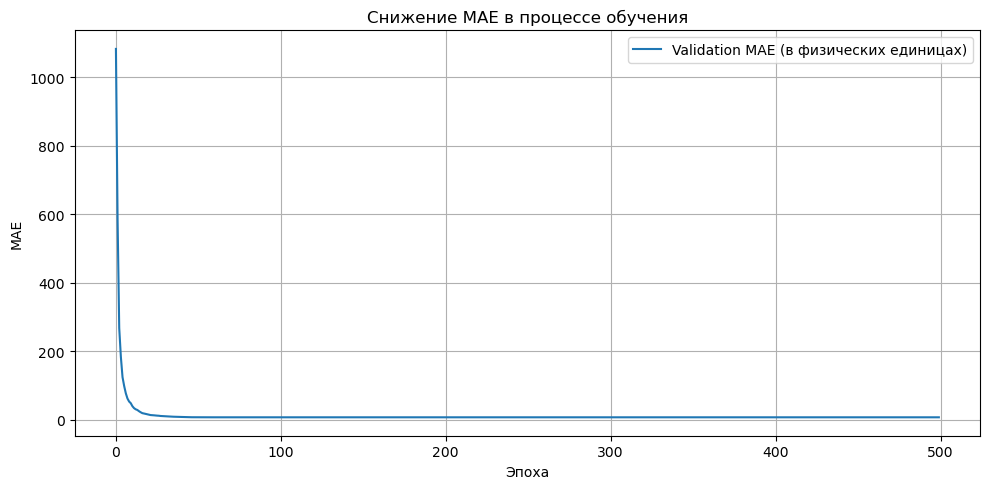

In [ ]:
# -------------------------------
# 7. График обучения
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(mae_history, label='Validation MAE (в физических единицах)')
plt.title('Снижение MAE в процессе обучения')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# -------------------------------
# 9. Сохранение модели
# -------------------------------
torch.save({
    'model_state_dict': model.state_dict(),
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
}, 'pinn_gravity_modelNSO.pth')
print("\nМодель сохранена!")


Модель сохранена!
